In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/PROG74040-AI-Text-Detection"
)

DATA_DIR = PROJECT_DIR / "data" / "splits"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

KAGGLE_TEST_FILE = DATA_DIR / "test.parquet"

print("Project exists:", PROJECT_DIR.exists())
print("Kaggle test exists:", KAGGLE_TEST_FILE.exists())

Project exists: True
Kaggle test exists: True


In [4]:
!pip install -q transformers datasets accelerate scikit-learn pyarrow

In [5]:
import pandas as pd
import numpy as np
import torch

from datasets import load_dataset, Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [6]:
hc3 = load_dataset(
    "json",
    data_files="hf://datasets/Hello-SimpleAI/HC3/all.jsonl"
)

hc3

all.jsonl: reconstructing file:   0%|          |  0.00B / 73.7MB            

all.jsonl: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'human_answers', 'chatgpt_answers', 'index', 'source'],
        num_rows: 24322
    })
})

In [7]:
rows = []

for item in hc3["train"]:

    for answer in item["human_answers"]:
        if answer and answer.strip():
            rows.append({
                "text": answer.strip(),
                "label": 0
            })

    for answer in item["chatgpt_answers"]:
        if answer and answer.strip():
            rows.append({
                "text": answer.strip(),
                "label": 1
            })

hc3_df = pd.DataFrame(rows)

print("Initial HC3 shape:", hc3_df.shape)

hc3_df.head()

Initial HC3 shape: (85431, 2)


,text,label
0,"Basically there are many categories of "" Best ...",0
1,"If you 're hearing about it , it 's because it...",0
2,"One reason is lots of catagories . However , h...",0
3,There are many different best seller lists tha...,1
4,salt is good for not dying in car crashes and ...,0


In [8]:
print(
    "Duplicates before removal:",
    hc3_df["text"].duplicated().sum()
)

hc3_df = hc3_df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

print("Final HC3 shape:", hc3_df.shape)

print("\nClass distribution:")
print(hc3_df["label"].value_counts())

Duplicates before removal: 6100
Final HC3 shape: (79331, 2)

Class distribution:
label
0    53086
1    26245
Name: count, dtype: int64


In [9]:
hc3_train_df, hc3_temp_df = train_test_split(
    hc3_df,
    test_size=0.30,
    stratify=hc3_df["label"],
    random_state=42
)

print("Train:", hc3_train_df.shape)
print("Temp:", hc3_temp_df.shape)

Train: (55531, 2)
Temp: (23800, 2)


In [10]:
hc3_val_df, hc3_test_df = train_test_split(
    hc3_temp_df,
    test_size=0.50,
    stratify=hc3_temp_df["label"],
    random_state=42
)

print("Train:", hc3_train_df.shape)
print("Validation:", hc3_val_df.shape)
print("Test:", hc3_test_df.shape)

Train: (55531, 2)
Validation: (11900, 2)
Test: (11900, 2)


In [11]:
for name, df in [
    ("Train", hc3_train_df),
    ("Validation", hc3_val_df),
    ("Test", hc3_test_df)
]:
    print(f"\n{name}")
    print(
        df["label"].value_counts(
            normalize=True
        )
    )


Train
label
0    0.669176
1    0.330824
Name: proportion, dtype: float64

Validation
label
0    0.66916
1    0.33084
Name: proportion, dtype: float64

Test
label
0    0.66916
1    0.33084
Name: proportion, dtype: float64


In [12]:
hc3_train_ds = Dataset.from_pandas(
    hc3_train_df,
    preserve_index=False
)

hc3_val_ds = Dataset.from_pandas(
    hc3_val_df,
    preserve_index=False
)

hc3_test_ds = Dataset.from_pandas(
    hc3_test_df,
    preserve_index=False
)

print(hc3_train_ds)
print(hc3_val_ds)
print(hc3_test_ds)

Dataset({
    features: ['text', 'label'],
    num_rows: 55531
})
Dataset({
    features: ['text', 'label'],
    num_rows: 11900
})
Dataset({
    features: ['text', 'label'],
    num_rows: 11900
})


In [13]:
MODEL_NAME = "FacebookAI/roberta-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded.")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizer loaded.


In [14]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [15]:
tokenized_train = hc3_train_ds.map(
    tokenize_function,
    batched=True
)

tokenized_val = hc3_val_ds.map(
    tokenize_function,
    batched=True
)

tokenized_test = hc3_test_ds.map(
    tokenize_function,
    batched=True
)

print(tokenized_train)
print(tokenized_val)
print(tokenized_test)

Map:   0%|          | 0/55531 [00:00<?, ? examples/s]

Map:   0%|          | 0/11900 [00:00<?, ? examples/s]

Map:   0%|          | 0/11900 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 55531
})
Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 11900
})
Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 11900
})


In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("RoBERTa model loaded.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa model loaded.


In [17]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=-1
    )[:, 1].numpy()

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            labels,
            probabilities
        )
    }

In [18]:
HC3_ROBERTA_CHECKPOINTS = (
    MODEL_DIR
    / "hc3_roberta_checkpoints"
)

training_args = TrainingArguments(
    output_dir=str(HC3_ROBERTA_CHECKPOINTS),

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=1,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=100,

    report_to="none",

    fp16=True,

    save_total_limit=1
)

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

In [20]:
print("Model:", MODEL_NAME)

print("HC3 training samples:", len(tokenized_train))
print("HC3 validation samples:", len(tokenized_val))
print("HC3 test samples:", len(tokenized_test))

print("Epochs:", training_args.num_train_epochs)
print(
    "Train batch:",
    training_args.per_device_train_batch_size
)

print("FP16:", training_args.fp16)

print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

Model: FacebookAI/roberta-base
HC3 training samples: 55531
HC3 validation samples: 11900
HC3 test samples: 11900
Epochs: 1
Train batch: 16
FP16: True
GPU: Tesla T4


In [21]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.000058,0.008230,0.998235,0.995696,0.998984,0.997337,0.999995


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [22]:
hc3_val_results = trainer.evaluate(
    tokenized_val
)

hc3_val_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.000058,0.008230,1,0.998235,0.995696,0.998984,0.997337,0.999995


{'eval_loss': 0.008230476640164852,
 'eval_accuracy': 0.9982352941176471,
 'eval_precision': 0.9956962025316456,
 'eval_recall': 0.998983997967996,
 'eval_f1': 0.99733739064283,
 'eval_roc_auc': 0.9999951196687524}

In [23]:
hc3_test_results = trainer.evaluate(
    tokenized_test,
    metric_key_prefix="hc3_test"
)

hc3_test_results

Training Loss,Validation Loss,Epoch,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1,Test Roc Auc
0.000058,No log,1,0.008330,0.998571,0.996203,0.999492,0.997845,0.999980


{'hc3_test_loss': 0.008330433629453182,
 'hc3_test_accuracy': 0.9985714285714286,
 'hc3_test_precision': 0.9962025316455696,
 'hc3_test_recall': 0.999491998983998,
 'hc3_test_f1': 0.9978445543299099,
 'hc3_test_roc_auc': 0.9999803510846503}

In [24]:
HC3_ROBERTA_FINAL = (
    MODEL_DIR
    / "hc3_roberta_final"
)

trainer.save_model(
    str(HC3_ROBERTA_FINAL)
)

tokenizer.save_pretrained(
    str(HC3_ROBERTA_FINAL)
)

print("Saved to:")
print(HC3_ROBERTA_FINAL)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to:
/content/drive/MyDrive/PROG74040-AI-Text-Detection/models/hc3_roberta_final


In [25]:
hc3_results_df = pd.DataFrame([{
    "model": "HC3-trained RoBERTa",
    "training_dataset": "HC3",
    "evaluation_dataset": "HC3",
    "accuracy": hc3_test_results["hc3_test_accuracy"],
    "precision": hc3_test_results["hc3_test_precision"],
    "recall": hc3_test_results["hc3_test_recall"],
    "f1": hc3_test_results["hc3_test_f1"],
    "roc_auc": hc3_test_results["hc3_test_roc_auc"]
}])

hc3_results_path = (
    OUTPUT_DIR
    / "hc3_trained_roberta_hc3_results.csv"
)

hc3_results_df.to_csv(
    hc3_results_path,
    index=False
)

print("Saved:")
print(hc3_results_path)

hc3_results_df

Saved:
/content/drive/MyDrive/PROG74040-AI-Text-Detection/outputs/hc3_trained_roberta_hc3_results.csv


,model,training_dataset,evaluation_dataset,accuracy,precision,recall,f1,roc_auc
0,HC3-trained RoBERTa,HC3,HC3,0.998571,0.996203,0.999492,0.997845,0.99998


In [26]:
kaggle_test_df = pd.read_parquet(
    KAGGLE_TEST_FILE
)

kaggle_test_df = kaggle_test_df[
    ["text", "generated"]
].copy()

kaggle_test_df = kaggle_test_df.rename(
    columns={
        "generated": "label"
    }
)

print("Kaggle test:", kaggle_test_df.shape)

kaggle_test_df.head()

Kaggle test: (73083, 2)


,text,label
0,"Dear principal TEACHER_NAME,\n\nI have heard t...",0
1,This is not valuable to have in a classroom wi...,0
2,"In my personal opinion, I think that it would ...",0
3,Facial Action Coding System (FACS) is a unique...,1
4,Have even seen the cowboys on TV and wanted to...,0


In [27]:
kaggle_test_ds = Dataset.from_pandas(
    kaggle_test_df,
    preserve_index=False
)

In [28]:
tokenized_kaggle_test = kaggle_test_ds.map(
    tokenize_function,
    batched=True
)

tokenized_kaggle_test

Map:   0%|          | 0/73083 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 73083
})

In [29]:
kaggle_prediction_output = trainer.predict(
    tokenized_kaggle_test
)

In [30]:
kaggle_logits = (
    kaggle_prediction_output.predictions
)

kaggle_labels = (
    kaggle_prediction_output.label_ids
)

kaggle_predictions = np.argmax(
    kaggle_logits,
    axis=-1
)

kaggle_probabilities = torch.softmax(
    torch.tensor(kaggle_logits),
    dim=-1
)[:, 1].numpy()

In [31]:
kaggle_results = {
    "accuracy": accuracy_score(
        kaggle_labels,
        kaggle_predictions
    ),

    "precision": precision_score(
        kaggle_labels,
        kaggle_predictions,
        zero_division=0
    ),

    "recall": recall_score(
        kaggle_labels,
        kaggle_predictions,
        zero_division=0
    ),

    "f1": f1_score(
        kaggle_labels,
        kaggle_predictions,
        zero_division=0
    ),

    "roc_auc": roc_auc_score(
        kaggle_labels,
        kaggle_probabilities
    )
}

kaggle_results

{'accuracy': 0.6706347577411984,
 'precision': 0.5338067570475575,
 'recall': 0.9115496270164994,
 'f1': 0.6733167759184615,
 'roc_auc': np.float64(0.8657802818388098)}

In [32]:
kaggle_results_df = pd.DataFrame([{
    "model": "HC3-trained RoBERTa",
    "training_dataset": "HC3",
    "evaluation_dataset": "Kaggle",
    **kaggle_results
}])

kaggle_results_path = (
    OUTPUT_DIR
    / "hc3_trained_roberta_kaggle_results.csv"
)

kaggle_results_df.to_csv(
    kaggle_results_path,
    index=False
)

print("Saved:")
print(kaggle_results_path)

kaggle_results_df

Saved:
/content/drive/MyDrive/PROG74040-AI-Text-Detection/outputs/hc3_trained_roberta_kaggle_results.csv


,model,training_dataset,evaluation_dataset,accuracy,precision,recall,f1,roc_auc
0,HC3-trained RoBERTa,HC3,Kaggle,0.670635,0.533807,0.91155,0.673317,0.86578


In [33]:
roberta_cross_direction = pd.DataFrame([
    {
        "Training Dataset": "Kaggle",
        "Evaluation Dataset": "Kaggle",
        "F1": 0.998642
    },

    {
        "Training Dataset": "Kaggle",
        "Evaluation Dataset": "HC3",
        "F1": 0.564608
    },

    {
        "Training Dataset": "HC3",
        "Evaluation Dataset": "HC3",
        "F1": hc3_test_results[
            "hc3_test_f1"
        ]
    },

    {
        "Training Dataset": "HC3",
        "Evaluation Dataset": "Kaggle",
        "F1": kaggle_results["f1"]
    }
])

roberta_cross_direction

,Training Dataset,Evaluation Dataset,F1
0,Kaggle,Kaggle,0.998642
1,Kaggle,HC3,0.564608
2,HC3,HC3,0.997845
3,HC3,Kaggle,0.673317


In [34]:
roberta_matrix = (
    roberta_cross_direction.pivot(
        index="Training Dataset",
        columns="Evaluation Dataset",
        values="F1"
    )
)

roberta_matrix

Evaluation Dataset,HC3,Kaggle
Training Dataset,,
HC3,0.997845,0.673317
Kaggle,0.564608,0.998642


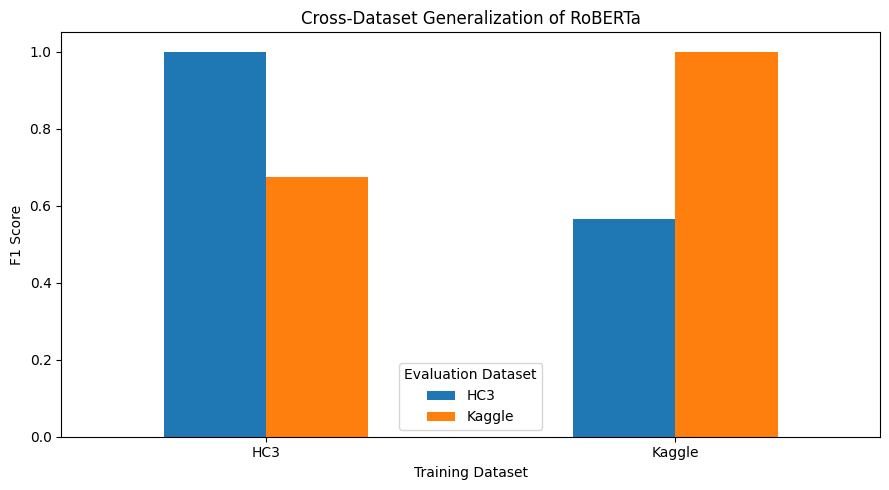

In [35]:
roberta_matrix.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Cross-Dataset Generalization of RoBERTa"
)

plt.ylabel("F1 Score")
plt.xlabel("Training Dataset")

plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [36]:
hc3_pred_output = trainer.predict(
    tokenized_test
)

hc3_logits = hc3_pred_output.predictions
hc3_labels = hc3_pred_output.label_ids

hc3_predictions = np.argmax(
    hc3_logits,
    axis=-1
)

hc3_probabilities = torch.softmax(
    torch.tensor(hc3_logits),
    dim=-1
)[:, 1].numpy()

hc3_prediction_df = hc3_test_df.copy()

hc3_prediction_df[
    "prediction"
] = hc3_predictions

hc3_prediction_df[
    "ai_probability"
] = hc3_probabilities

hc3_prediction_df.to_csv(
    OUTPUT_DIR
    / "hc3_trained_roberta_hc3_predictions.csv",
    index=False
)

print("HC3 predictions saved.")

HC3 predictions saved.


In [37]:
kaggle_prediction_df = (
    kaggle_test_df.copy()
)

kaggle_prediction_df[
    "prediction"
] = kaggle_predictions

kaggle_prediction_df[
    "ai_probability"
] = kaggle_probabilities

kaggle_prediction_df.to_csv(
    OUTPUT_DIR
    / "hc3_trained_roberta_kaggle_predictions.csv",
    index=False
)

print("Kaggle predictions saved.")

Kaggle predictions saved.


In [38]:
# Free RoBERTa objects from GPU memory

import gc
import torch

del model
del trainer

torch.cuda.empty_cache()
gc.collect()

print("GPU memory cleared.")

GPU memory cleared.


In [39]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

DEBERTA_MODEL_NAME = "microsoft/deberta-base"

deberta_tokenizer = AutoTokenizer.from_pretrained(
    DEBERTA_MODEL_NAME
)

deberta_model = AutoModelForSequenceClassification.from_pretrained(
    DEBERTA_MODEL_NAME,
    num_labels=2
)

print("DeBERTa loaded.")

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  559MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DeBERTa loaded.


In [40]:
def deberta_tokenize_function(batch):
    return deberta_tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [41]:
deberta_tokenized_train = hc3_train_ds.map(
    deberta_tokenize_function,
    batched=True
)

deberta_tokenized_val = hc3_val_ds.map(
    deberta_tokenize_function,
    batched=True
)

deberta_tokenized_test = hc3_test_ds.map(
    deberta_tokenize_function,
    batched=True
)

print(deberta_tokenized_train)
print(deberta_tokenized_val)
print(deberta_tokenized_test)

Map:   0%|          | 0/55531 [00:00<?, ? examples/s]

Map:   0%|          | 0/11900 [00:00<?, ? examples/s]

Map:   0%|          | 0/11900 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 55531
})
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 11900
})
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 11900
})


In [42]:
HC3_DEBERTA_CHECKPOINTS = (
    MODEL_DIR
    / "hc3_deberta_checkpoints"
)

deberta_training_args = TrainingArguments(
    output_dir=str(HC3_DEBERTA_CHECKPOINTS),

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=1,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=100,

    report_to="none",

    fp16=False,

    save_total_limit=1
)

In [43]:
deberta_trainer = Trainer(
    model=deberta_model,
    args=deberta_training_args,
    train_dataset=deberta_tokenized_train,
    eval_dataset=deberta_tokenized_val,
    compute_metrics=compute_metrics
)

In [44]:
print("Model:", DEBERTA_MODEL_NAME)
print("Train:", len(deberta_tokenized_train))
print("Validation:", len(deberta_tokenized_val))
print("Test:", len(deberta_tokenized_test))
print("GPU:", torch.cuda.get_device_name(0))
print("FP16:", deberta_training_args.fp16)

Model: microsoft/deberta-base
Train: 55531
Validation: 11900
Test: 11900
GPU: Tesla T4
FP16: False


In [45]:
deberta_train_result = deberta_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.000069,0.009908,0.998067,0.994692,0.999492,0.997086,0.999989


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [46]:
deberta_hc3_test_results = deberta_trainer.evaluate(
    deberta_tokenized_test,
    metric_key_prefix="hc3_test"
)

deberta_hc3_test_results

Training Loss,Validation Loss,Epoch,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1,Test Roc Auc
0.000069,No log,1,0.006929,0.998739,0.996456,0.999746,0.998098,0.999991


{'hc3_test_loss': 0.006929353345185518,
 'hc3_test_accuracy': 0.9987394957983193,
 'hc3_test_precision': 0.9964556962025316,
 'hc3_test_recall': 0.9997459994919989,
 'hc3_test_f1': 0.99809813617345,
 'hc3_test_roc_auc': 0.9999912600603802}

In [47]:
HC3_DEBERTA_FINAL = (
    MODEL_DIR
    / "hc3_deberta_final"
)

deberta_trainer.save_model(
    str(HC3_DEBERTA_FINAL)
)

deberta_tokenizer.save_pretrained(
    str(HC3_DEBERTA_FINAL)
)

print("Saved to:")
print(HC3_DEBERTA_FINAL)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to:
/content/drive/MyDrive/PROG74040-AI-Text-Detection/models/hc3_deberta_final


In [49]:
deberta_tokenized_kaggle = kaggle_test_ds.map(
    deberta_tokenize_function,
    batched=True
)

print(deberta_tokenized_kaggle)

Map:   0%|          | 0/73083 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 73083
})


In [50]:
deberta_kaggle_output = deberta_trainer.predict(
    deberta_tokenized_kaggle
)

In [51]:
deberta_kaggle_logits = deberta_kaggle_output.predictions
deberta_kaggle_labels = deberta_kaggle_output.label_ids

deberta_kaggle_predictions = np.argmax(
    deberta_kaggle_logits,
    axis=-1
)

deberta_kaggle_probabilities = torch.softmax(
    torch.tensor(deberta_kaggle_logits),
    dim=-1
)[:, 1].numpy()

In [52]:
deberta_kaggle_results = {
    "accuracy": accuracy_score(
        deberta_kaggle_labels,
        deberta_kaggle_predictions
    ),
    "precision": precision_score(
        deberta_kaggle_labels,
        deberta_kaggle_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        deberta_kaggle_labels,
        deberta_kaggle_predictions,
        zero_division=0
    ),
    "f1": f1_score(
        deberta_kaggle_labels,
        deberta_kaggle_predictions,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        deberta_kaggle_labels,
        deberta_kaggle_probabilities
    )
}

deberta_kaggle_results

{'accuracy': 0.5426980282692281,
 'precision': 0.4470433684785205,
 'recall': 0.9628853856612648,
 'f1': 0.610600393815466,
 'roc_auc': np.float64(0.851654898007612)}

In [53]:
deberta_kaggle_results_df = pd.DataFrame([{
    "model": "HC3-trained DeBERTa",
    "training_dataset": "HC3",
    "evaluation_dataset": "Kaggle",
    **deberta_kaggle_results
}])

deberta_kaggle_results_df.to_csv(
    OUTPUT_DIR / "hc3_trained_deberta_kaggle_results.csv",
    index=False
)

deberta_kaggle_results_df

,model,training_dataset,evaluation_dataset,accuracy,precision,recall,f1,roc_auc
0,HC3-trained DeBERTa,HC3,Kaggle,0.542698,0.447043,0.962885,0.6106,0.851655


In [54]:
deberta_kaggle_prediction_df = kaggle_test_df.copy()

deberta_kaggle_prediction_df[
    "prediction"
] = deberta_kaggle_predictions

deberta_kaggle_prediction_df[
    "ai_probability"
] = deberta_kaggle_probabilities

deberta_kaggle_prediction_df.to_csv(
    OUTPUT_DIR / "hc3_trained_deberta_kaggle_predictions.csv",
    index=False
)

print("DeBERTa Kaggle predictions saved.")

DeBERTa Kaggle predictions saved.


In [55]:
final_cross_dataset = pd.DataFrame([
    {
        "Model": "SVM",
        "Training Dataset": "Kaggle",
        "Same-Dataset F1": 0.9992,
        "Cross-Dataset F1": 0.5702
    },
    {
        "Model": "SVM",
        "Training Dataset": "HC3",
        "Same-Dataset F1": 0.934389,
        "Cross-Dataset F1": 0.684138
    },
    {
        "Model": "RoBERTa",
        "Training Dataset": "Kaggle",
        "Same-Dataset F1": 0.998642,
        "Cross-Dataset F1": 0.564608
    },
    {
        "Model": "RoBERTa",
        "Training Dataset": "HC3",
        "Same-Dataset F1": 0.997845,
        "Cross-Dataset F1": 0.673317
    },
    {
        "Model": "DeBERTa",
        "Training Dataset": "Kaggle",
        "Same-Dataset F1": 0.9948,
        "Cross-Dataset F1": 0.5688
    },
    {
        "Model": "DeBERTa",
        "Training Dataset": "HC3",
        "Same-Dataset F1": 0.998098,
        "Cross-Dataset F1": 0.610600
    }
])

final_cross_dataset

,Model,Training Dataset,Same-Dataset F1,Cross-Dataset F1
0,SVM,Kaggle,0.999200,0.570200
1,SVM,HC3,0.934389,0.684138
2,RoBERTa,Kaggle,0.998642,0.564608
3,RoBERTa,HC3,0.997845,0.673317
4,DeBERTa,Kaggle,0.994800,0.568800
5,DeBERTa,HC3,0.998098,0.610600


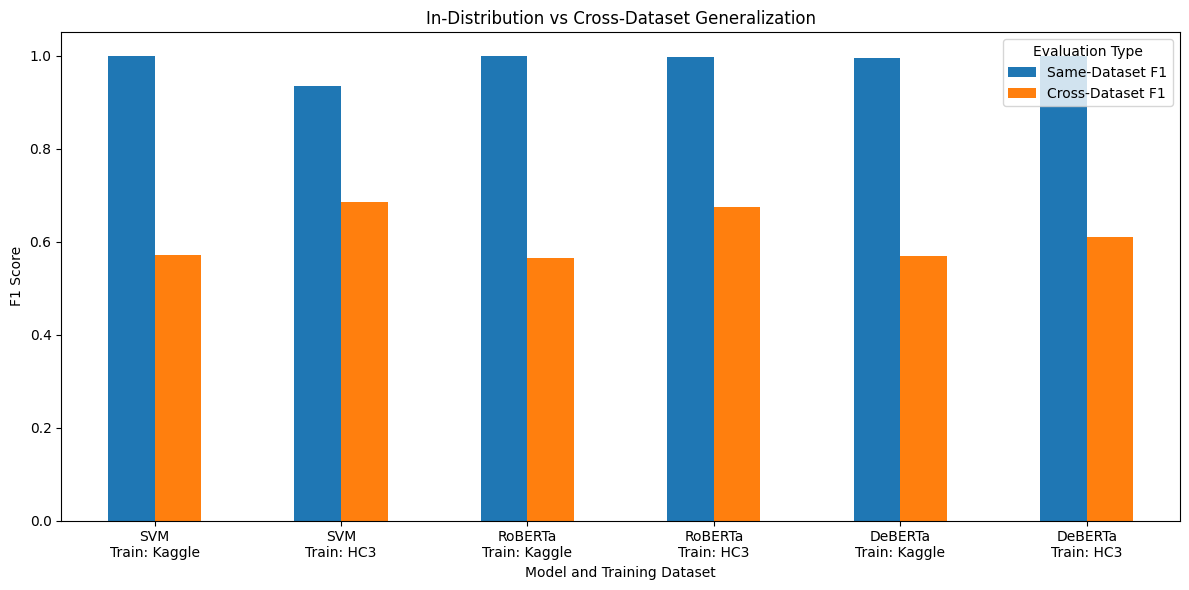

In [56]:
plot_df = final_cross_dataset.copy()

plot_df["Experiment"] = (
    plot_df["Model"]
    + "\nTrain: "
    + plot_df["Training Dataset"]
)

plot_df.set_index("Experiment")[
    ["Same-Dataset F1", "Cross-Dataset F1"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "In-Distribution vs Cross-Dataset Generalization"
)

plt.ylabel("F1 Score")
plt.xlabel("Model and Training Dataset")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Evaluation Type"
)

plt.tight_layout()
plt.show()